# 04 — Merkmalskonstruktion

Ziel dieses Notebooks sind abgeleitete Merkmale, die Fachwissen
einbringen — und zwar innerhalb der Pipeline, nicht daneben.

Zwei Fragen werden beantwortet: Bringen die Merkmale messbar etwas? Und warum
muss ihre Berechnung Teil des Modellobjekts sein statt eine Zelle im Notebook?

Gearbeitet wird weiterhin auf Training und Validierung.

In [1]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

from src.data.split import lade_teilmengen, trenne_merkmale_und_ziel
from src.data.validate import load_params
from src.features.build_features import (
    ABGELEITETE_MERKMALE,
    add_engineered_features,
    baue_pipeline,
)
from src.utils.plotting import FARBEN, nur_x_gitter, nur_y_gitter, setze_stil, speichere

import matplotlib.pyplot as plt

setze_stil()
params = load_params()
seed = params["seed"]

train, val, _ = lade_teilmengen()
X_train, y_train = trenne_merkmale_und_ziel(train, params)
X_val, y_val = trenne_merkmale_und_ziel(val, params)

print(f"Rohmerkmale: {list(X_train.columns)}")

Rohmerkmale: ['type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']


## 1 Neue Features

Die Auswahl dieser Merkmale basiert auf den physikalischen Zusammenhängen innerhalb der Maschine. Drei Merkmale sind dabei besonders relevant, da sie jeweils einen Bezug zu einer der dokumentierten Ausfallarten haben.

**Temperaturdifferenz** `temp_difference_k = process_temperature_k − air_temperature_k`

Wie viel wärmer wird der Prozess gegenüber der Umgebung — also wie gut die Wärme
abgeführt wird. Genau darum geht es bei der Ausfallart `HDF` (Heat Dissipation
Failure). Nebeneffekt: Die beiden Temperaturen korrelieren mit 0,88, ihr
gemeinsamer Anteil trägt kaum Information. Die Differenz ersetzt ihn durch die
aussagekräftige Größe.

**Mechanische Leistung** `power_w = torque_nm · 2π · rotational_speed_rpm / 60`

Die Standardformel P = M · ω. Sie fasst Drehmoment und Drehzahl zusammen, die
mit −0,88 stark gegenläufig sind. In Notebook 01 lagen die Ausfälle an beiden
Rändern des Betriebsbereichs — hohe Last bei niedriger Drehzahl und umgekehrt.
Ein Baum braucht dafür zwei getrennte Regionen; mit der Leistung wird daraus
eine auffällige Zahl.

**Verschleiß unter Last** `wear_torque_min_nm = tool_wear_min · torque_nm`

Ein verschlissenes Werkzeug unter hoher Last ist gefährlicher als beides für
sich genommen. Das ist die Logik hinter der Ausfallart `OSF` (Überlastung), die
im Datensatz als Produkt aus Verschleiß und Drehmoment erzeugt wird.

In [2]:
beispiel = add_engineered_features(X_train)

print("vorher :", X_train.shape[1], "Spalten")
print("nachher:", beispiel.shape[1], "Spalten")
print()
beispiel[list(ABGELEITETE_MERKMALE)].describe().T[["min", "mean", "max"]].round(1)

vorher : 6 Spalten
nachher: 9 Spalten



,min,mean,max
temp_difference_k,7.6,10.0,12.1
power_w,1148.4,6280.4,10469.9
wear_torque_min_nm,0.0,4310.2,14999.5


## 2 Vergleich neue Features

Gleiche Verfahren, gleiche Aufteilung, eine Startwert — einmal mit, einmal
ohne die drei Merkmale. Geprüft werden beide Verfahren.

In [3]:
verfahren = {
    "Logistische Regression": (
        LogisticRegression(max_iter=1000, random_state=seed), True,
    ),
    "Random Forest": (
        RandomForestClassifier(n_estimators=300, max_depth=15,
                               random_state=seed, n_jobs=-1), False,
    ),
}

zeilen = []
for name, (modell, skalieren) in verfahren.items():
    werte = {}
    for mit_merkmalen in (False, True):
        pipeline = baue_pipeline(clone(modell), mit_merkmalen=mit_merkmalen,
                                 skalieren=skalieren)
        pipeline.fit(X_train, y_train)
        schluessel = "mit Merkmalen" if mit_merkmalen else "ohne Merkmale"
        werte[schluessel] = average_precision_score(
            y_val, pipeline.predict_proba(X_val)[:, 1]
        )
    werte["Zugewinn"] = werte["mit Merkmalen"] - werte["ohne Merkmale"]
    zeilen.append({"Verfahren": name, **werte})

merkmalsvergleich = pd.DataFrame(zeilen).set_index("Verfahren")
merkmalsvergleich.round(3)

,ohne Merkmale,mit Merkmalen,Zugewinn
Verfahren,,,
Logistische Regression,0.357,0.412,0.055
Random Forest,0.743,0.843,0.100


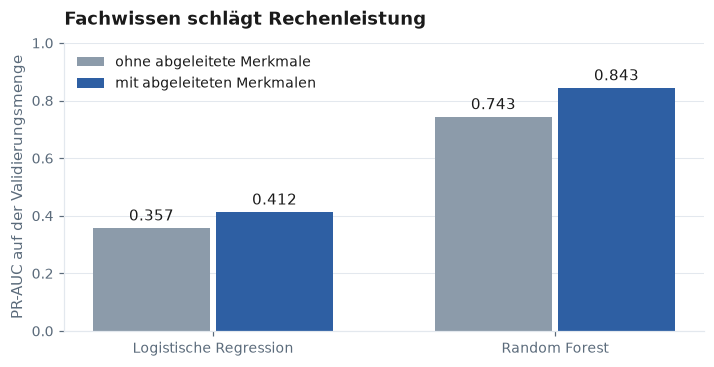

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))

positionen = np.arange(len(merkmalsvergleich))
breite = 0.34

ax.bar(positionen - breite / 2 - 0.01, merkmalsvergleich["ohne Merkmale"],
       width=breite, color=FARBEN["neutral"], label="ohne abgeleitete Merkmale")
ax.bar(positionen + breite / 2 + 0.01, merkmalsvergleich["mit Merkmalen"],
       width=breite, color=FARBEN["kein_ausfall"], label="mit abgeleiteten Merkmalen")

for i, (ohne, mit) in enumerate(zip(merkmalsvergleich["ohne Merkmale"],
                                    merkmalsvergleich["mit Merkmalen"])):
    ax.text(i - breite / 2 - 0.01, ohne + 0.015, f"{ohne:.3f}",
            ha="center", va="bottom", fontsize=9.5, color=FARBEN["text"])
    ax.text(i + breite / 2 + 0.01, mit + 0.015, f"{mit:.3f}",
            ha="center", va="bottom", fontsize=9.5, color=FARBEN["text"])

ax.set_xticks(positionen, list(merkmalsvergleich.index))
ax.set_ylabel("PR-AUC auf der Validierungsmenge")
ax.set_ylim(0, 1.0)
ax.set_title("Fachwissen schlägt Rechenleistung", loc="left")
ax.legend(loc="upper left")
nur_y_gitter(ax)

speichere(fig, "10_merkmale_vergleich")
plt.show()

Beide Verfahren gewinnen: 
Die logistische Regression steigt von 0,357 auf 0,412 (+0,055), 
der Random Forest von 0,743 auf 0,843 (+0,101).

**Der Zugewinn von rund 0,10 beim Random Forest ist der eigentliche Befund.**
Fachwissen, das man dem Modell schenkt, ist wirksamer und es ist erklärbar.

Auch die logistische Regression erzielt durch die zusätzliche Variable `power_w` bessere Ergebnisse. Da `power_w` aus der Kombination zweier Merkmale berechnet wird, erhält das lineare Modell dadurch zusätzliche Informationen über deren Zusammenhang. Trotzdem bleibt die Leistung hinter dem Baummodell zurück. Die neue Variable verbessert zwar die Abbildung komplexerer Zusammenhänge, beseitigt jedoch nicht die grundlegenden Einschränkungen des linearen Modells.

*Kleine Abweichung gegenüber Notebook 02:* Dort lag der Random Forest ohne
Merkmale bei 0,738, hier bei 0,743. Grund ist die One-hot-Kodierung, die hier
eine Referenzkategorie weglässt (`drop="first"`). Der Unterschied ist Rauschen,
kein Effekt.

## 3 Relevante Merkmale

In [5]:
bestes = baue_pipeline(
    RandomForestClassifier(n_estimators=300, max_depth=15, random_state=seed, n_jobs=-1),
    mit_merkmalen=True, skalieren=False,
)
bestes.fit(X_train, y_train)

namen = [
    n.split("__", 1)[1]
    for n in bestes.named_steps["vorverarbeitung"].get_feature_names_out()
]
wichtigkeit = (
    pd.Series(bestes.named_steps["modell"].feature_importances_, index=namen)
    .sort_values()
)
wichtigkeit.round(3).to_frame("Wichtigkeit")

,Wichtigkeit
type_M,0.011
type_L,0.021
process_temperature_k,0.037
air_temperature_k,0.041
tool_wear_min,0.056
temp_difference_k,0.118
torque_nm,0.134
rotational_speed_rpm,0.165
wear_torque_min_nm,0.204
power_w,0.212


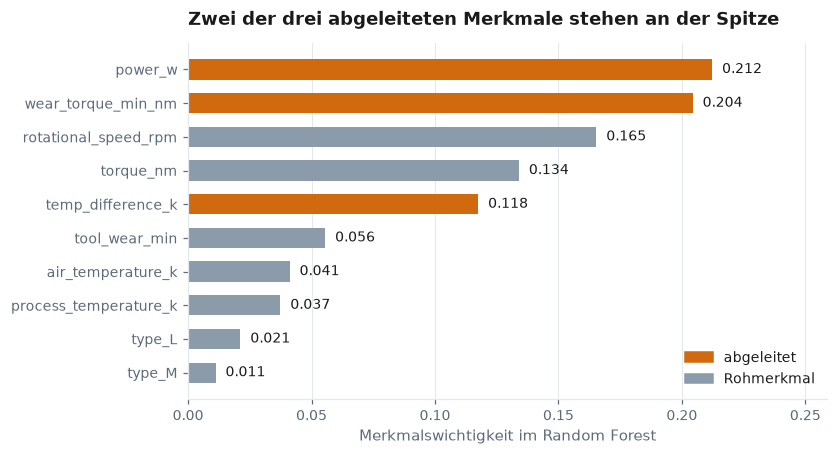

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

ist_abgeleitet = [n in ABGELEITETE_MERKMALE for n in wichtigkeit.index]
farben = [FARBEN["ausfall"] if a else FARBEN["neutral"] for a in ist_abgeleitet]

ax.barh(range(len(wichtigkeit)), wichtigkeit.to_numpy(), height=0.6, color=farben)
for i, wert in enumerate(wichtigkeit):
    ax.text(wert + 0.004, i, f"{wert:.3f}", va="center", ha="left",
            fontsize=9, color=FARBEN["text"])

ax.set_yticks(range(len(wichtigkeit)), list(wichtigkeit.index))
ax.set_xlim(0, wichtigkeit.max() * 1.22)
ax.set_xlabel("Merkmalswichtigkeit im Random Forest")
ax.set_title("Zwei der drei abgeleiteten Merkmale stehen an der Spitze", loc="left")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=FARBEN["ausfall"], label="abgeleitet"),
    Patch(color=FARBEN["neutral"], label="Rohmerkmal"),
], loc="lower right")
nur_x_gitter(ax)

speichere(fig, "11_merkmalswichtigkeit")
plt.show()

In [7]:
anteil_abgeleitet = wichtigkeit[list(ABGELEITETE_MERKMALE)].sum()
print(f"Anteil der abgeleiteten Merkmale an der Gesamtwichtigkeit: {anteil_abgeleitet:.1%}")

Anteil der abgeleiteten Merkmale an der Gesamtwichtigkeit: 53.4%


`power_w` und `wear_torque_min_nm` belegen die ersten beiden Plätze, zusammen mit
`temp_difference_k` tragen die drei abgeleiteten Merkmale gut die Hälfte der
Gesamtwichtigkeit. Die beiden Einzeltemperaturen, aus denen die Differenz
gebildet wird, fallen entsprechend ab.

Bei der Interpretation der Merkmalswichtigkeit des Random Forest ist jedoch Vorsicht geboten. Merkmale mit vielen möglichen Aufteilungspunkten können eine höhere Bedeutung erhalten, während sich die Bedeutung bei stark miteinander verbundenen Merkmalen auf mehrere Variablen verteilt. Die Merkmalswichtigkeit eignet sich daher gut, um eine **grobe Einschätzung der relevanten Merkmale** zu erhalten, sollte jedoch nicht als exakte Messung ihres tatsächlichen Einflusses interpretiert werden.


## 4 Warum die Berechnung in die Pipeline gehört

Die zusätzlichen Merkmale werden nicht separat im Notebook erzeugt, sondern direkt als Bestandteil der Pipeline berechnet. Dadurch sind Feature Engineering und Modellierung in einem gemeinsamen Verarbeitungsschritt verbunden.

Die Berechnung wird über einen `FunctionTransformer` in die Pipeline integriert und ist damit Bestandteil des gespeicherten Modellobjekts. Die Schnittstelle arbeitet ausschließlich mit den ursprünglichen Eingabewerten und überlässt der Pipeline die weitere Verarbeitung.

Die trainierte Pipeline erhält einen DataFrame, der ausschließlich die sechs Rohspalten enthält. Merkmale wie `temp_difference_k` oder die berechnete Leistung sind nicht im Eingabedatensatz enthalten und werden erst innerhalb der Pipeline erzeugt.


In [8]:
rohanfrage = pd.DataFrame([{
    "type": "L",
    "air_temperature_k": 302.3,
    "process_temperature_k": 311.5,
    "rotational_speed_rpm": 1320,
    "torque_nm": 62.4,
    "tool_wear_min": 215,
}])

print("übergebene Spalten:", list(rohanfrage.columns))
print("abgeleitete Merkmale darin:",
      [m for m in ABGELEITETE_MERKMALE if m in rohanfrage.columns] or "keine")
print()
print(f"Ausfallwahrscheinlichkeit: {bestes.predict_proba(rohanfrage)[0, 1]:.3f}")

übergebene Spalten: ['type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']
abgeleitete Merkmale darin: keine

Ausfallwahrscheinlichkeit: 0.980


---

## Summary

| Befund | Zahl |
|---|---|
| Zugewinn durch Merkmale, Random Forest | +0,101 PR-AUC (0,743 → 0,843) |
| Zugewinn durch Merkmale, logistische Regression | +0,055 PR-AUC (0,357 → 0,412) |
| Anteil der abgeleiteten Merkmale an der Wichtigkeit | rund 53 % |
| logistische Regression ohne Merkmale | 0,357 |
| vorab festgelegre Erfolgsschwelle | 0,75 |

Der Random Forest liegt mit 0,843 bereits über der Erfolgsschwelle — **bevor**
ein einziger Hyperparameter abgestimmt wurde. 